In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
car_price=pd.read_csv("/content/CarPrice_Assignment.csv")
car_price.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
car_price.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
car_price.shape

(205, 26)

In [ ]:
car_price = car_price.drop('car_ID', axis=1)

**Data Visualization**

To perform linear regression, the (numeric) target variable should be linearly related to at least one another numeric variable. Let's see whether that's true in this case.

We'll first subset the list of all (independent) numeric variables, and then make a pairwise plot.

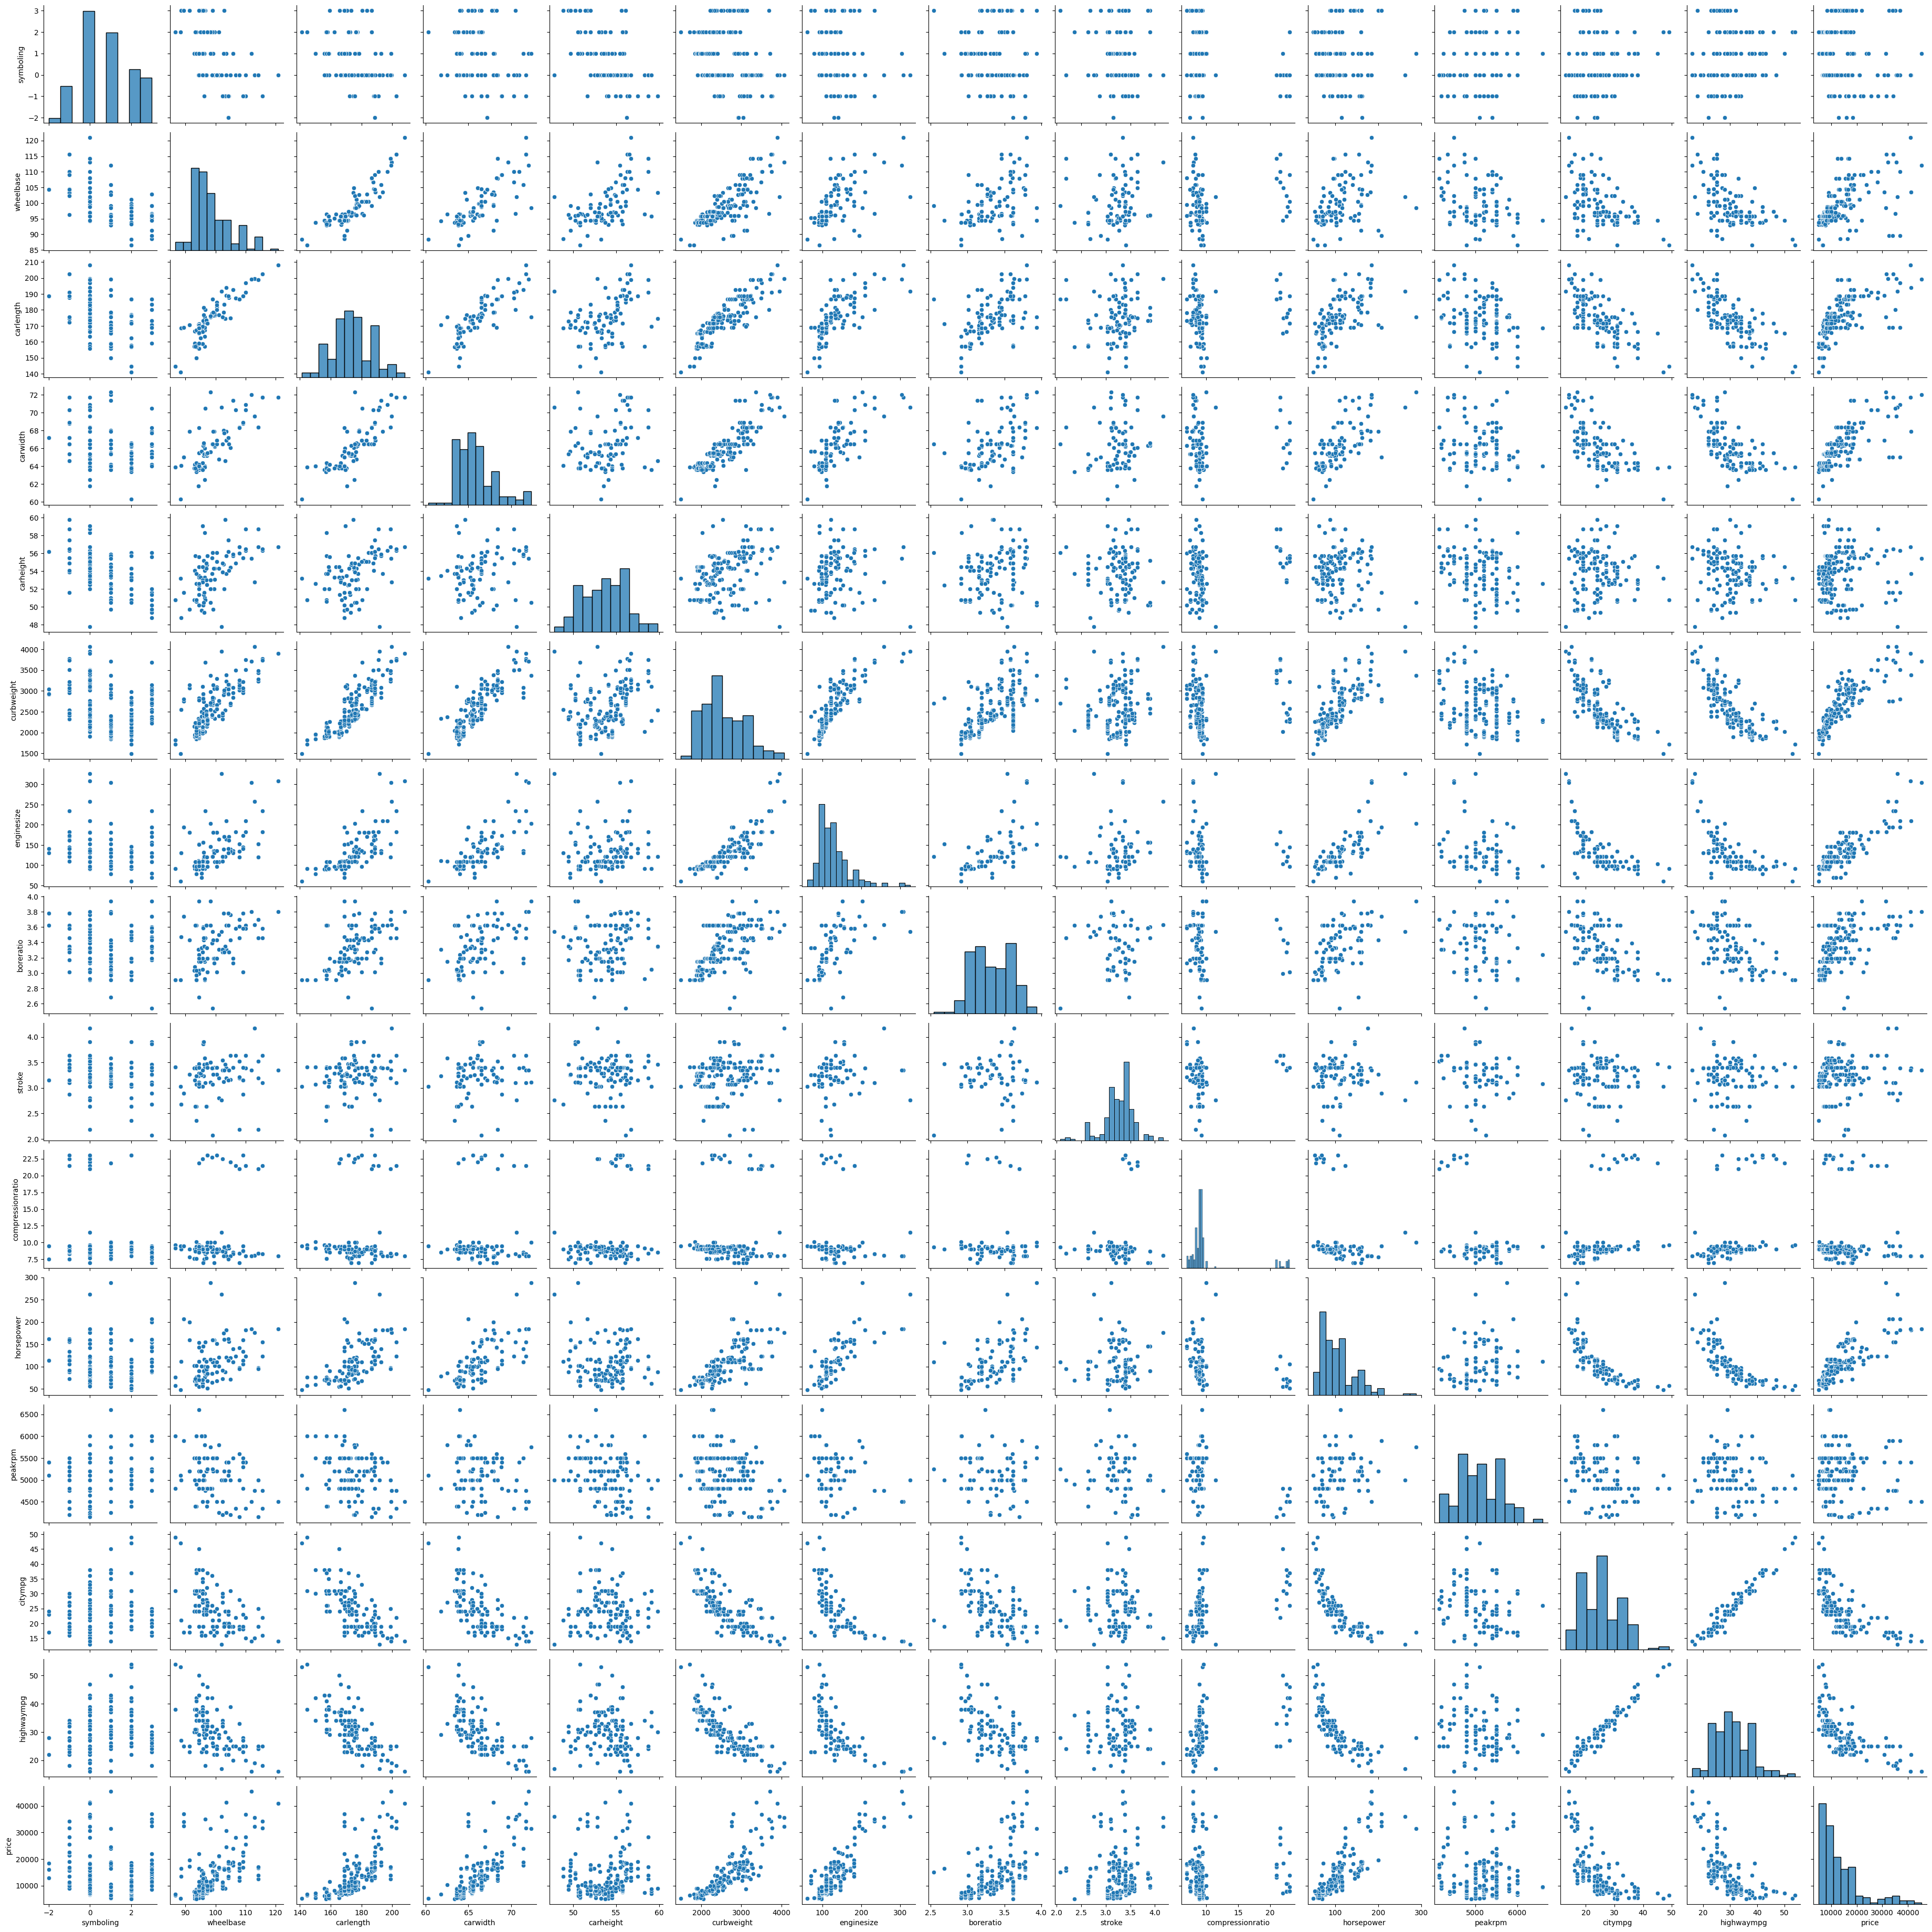

In [ ]:
sns.pairplot(car_price)
plt.show()

This is quite hard to read, and we can rather plot correlations between variables. Also, a heatmap is pretty useful to visualise multiple correlations in one plot.

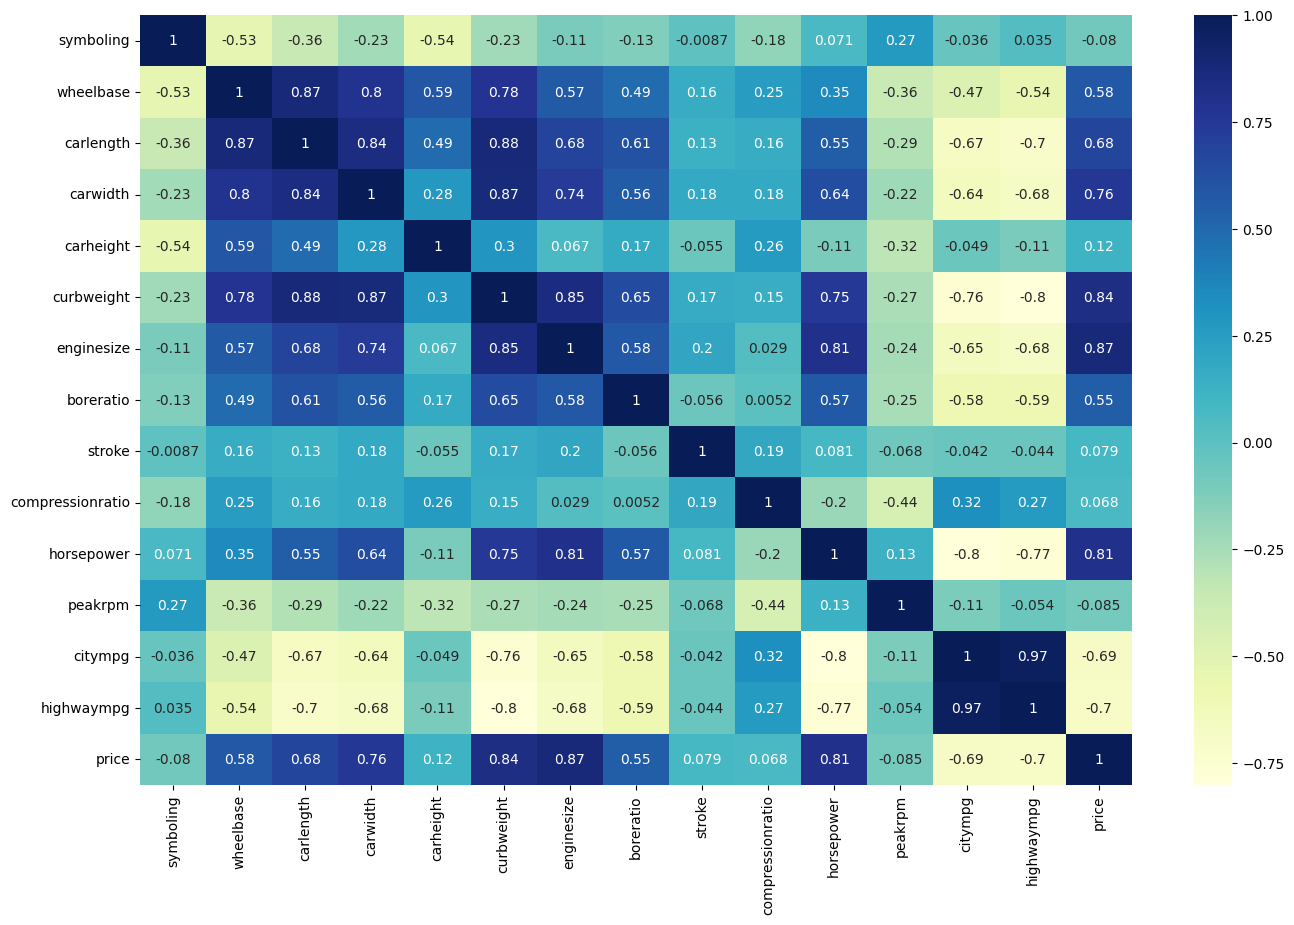

In [ ]:
#Correlation plot
plt.figure(figsize=(16,10))
sns.heatmap(car_price.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="YlGnBu")
plt.show()

The heatmap shows some useful insights:

Correlation of price with independent variables:

Price is highly (positively) correlated with wheelbase, carlength, carwidth, curbweight, enginesize, horsepower (notice how all of these variables represent the size/weight/engine power of the car)

Price is negatively correlated to citympg and highwaympg (-0.70 approximately). This suggest that cars having high mileage may fall in the 'economy' cars category, and are priced lower (think Maruti Alto/Swift type of cars, which are designed to be affordable by the middle class, who value mileage more than horsepower/size of car etc.)

Correlation among independent variables:

Many independent variables are highly correlated (look at the top-left part of matrix): wheelbase, carlength, curbweight, enginesize etc. are all measures of 'size/weight', and are positively correlated
Thus, while building the model, we'll have to pay attention to multicollinearity.

Data Cleaning

In [ ]:
car_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   CarName           205 non-null    object 
 2   fueltype          205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumber        205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheel        205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    int64  
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    int64  
 16  fuelsystem        205 non-null    object 
 1

In [ ]:
car_price.CarName.value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [ ]:
car_price['CarCompany'] = car_price['CarName'].str.split().str[0]

In [ ]:
car_price.CarCompany.value_counts()

,count
CarCompany,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


As per our requirement we only need car company name, so

In [ ]:
car_price.CarCompany.value_counts()

,count
CarCompany,
toyota,31
nissan,17
mazda,15
honda,13
mitsubishi,13
subaru,12
volvo,11
peugeot,11
dodge,9


In [ ]:
car_price.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarCompany
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


Step 4: Preparing Data for model

Maping and creating dummy variables

In [ ]:
car_price.cylindernumber.value_counts()

,count
cylindernumber,
four,159
six,24
five,11
eight,5
two,4
twelve,1
three,1


In [ ]:
cylinder_mapping = {'four': 4, 'six': 6, 'five': 5, 'eight': 8, 'two': 2, 'three': 3, 'twelve': 12}

car_price['cylindernumber'] = car_price['cylindernumber'].map(cylinder_mapping)
car_price.cylindernumber.value_counts()

,count
cylindernumber,
4,159
6,24
5,11
8,5
2,4
12,1
3,1


In [ ]:
car_price.doornumber.value_counts()

,count
doornumber,
four,115
two,90


In [ ]:
car_price['doornumber'] = car_price['doornumber'].map({'four': 4, 'two': 2})
car_price.doornumber.value_counts()

,count
doornumber,
4,115
2,90


In [ ]:
# Subset all categorical variables
cars_categorical = car_price.select_dtypes(include=['object'])
cars_categorical.head()

,CarName,fueltype,aspiration,carbody,drivewheel,enginelocation,enginetype,fuelsystem,CarCompany
0,alfa-romero giulia,gas,std,convertible,rwd,front,dohc,mpfi,alfa-romero
1,alfa-romero stelvio,gas,std,convertible,rwd,front,dohc,mpfi,alfa-romero
2,alfa-romero Quadrifoglio,gas,std,hatchback,rwd,front,ohcv,mpfi,alfa-romero
3,audi 100 ls,gas,std,sedan,fwd,front,ohc,mpfi,audi
4,audi 100ls,gas,std,sedan,4wd,front,ohc,mpfi,audi


In [ ]:
status=pd.get_dummies(cars_categorical,drop_first=True).astype(int)
status.head()

,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,...,CarCompany_porsche,CarCompany_renault,CarCompany_saab,CarCompany_subaru,CarCompany_toyota,CarCompany_toyouta,CarCompany_vokswagen,CarCompany_volkswagen,CarCompany_volvo,CarCompany_vw
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# concate the dummy vars df with original one
car_price=pd.concat([car_price,status],axis=1)
car_price.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,CarCompany_porsche,CarCompany_renault,CarCompany_saab,CarCompany_subaru,CarCompany_toyota,CarCompany_toyouta,CarCompany_vokswagen,CarCompany_volkswagen,CarCompany_volvo,CarCompany_vw
0,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,168.8,...,0,0,0,0,0,0,0,0,0,0
1,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,168.8,...,0,0,0,0,0,0,0,0,0,0
2,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,171.2,...,0,0,0,0,0,0,0,0,0,0
3,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,176.6,...,0,0,0,0,0,0,0,0,0,0
4,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,176.6,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
car_price = car_price.drop(list(cars_categorical.columns), axis=1)
car_price.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,CarCompany_porsche,CarCompany_renault,CarCompany_saab,CarCompany_subaru,CarCompany_toyota,CarCompany_toyouta,CarCompany_vokswagen,CarCompany_volkswagen,CarCompany_volvo,CarCompany_vw
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0,0,0,0,0,0,0,0,0,0
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0,0,0,0,0,0,0,0,0,0
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,0,0,0,0,0,0,0,0,0,0
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,0,0,0,0,0,0,0,0,0,0
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0,0,0,0,0,0,0,0,0,0


 Splitting the Data into Training and Testing Sets


In [ ]:
df_train, df_test=train_test_split(car_price,train_size=0.7,test_size=0.3,random_state=100)
print(df_train.shape)
print(df_test.shape)

(143, 212)
(62, 212)


In [ ]:
scaler = StandardScaler()

# Create a list of the variables that you need to scale
numeric = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight','curbweight', 'enginesize', 'boreratio', 'stroke',
           'compressionratio','horsepower', 'peakrpm', 'citympg', 'highwaympg', 'doornumber', 'cylindernumber', 'price']

# Scale these variables using 'fit_transform'
df_train[numeric] = scaler.fit_transform(df_train[numeric])

In [ ]:
y_train=df_train.pop('price')
X_train=df_train

Model Building

In [ ]:
lm=LinearRegression()

lm.fit(X_train,y_train)

rfe = RFE(estimator=lm,n_features_to_select= 10)             # running RFE
rfe = rfe.fit(X_train, y_train)

In [ ]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('symboling', np.False_, np.int64(124)),
 ('doornumber', np.False_, np.int64(118)),
 ('wheelbase', np.False_, np.int64(85)),
 ('carlength', np.False_, np.int64(82)),
 ('carwidth', np.False_, np.int64(37)),
 ('carheight', np.False_, np.int64(161)),
 ('curbweight', np.False_, np.int64(166)),
 ('cylindernumber', np.False_, np.int64(47)),
 ('enginesize', np.False_, np.int64(48)),
 ('boreratio', np.False_, np.int64(49)),
 ('stroke', np.False_, np.int64(52)),
 ('compressionratio', np.False_, np.int64(6)),
 ('horsepower', np.False_, np.int64(13)),
 ('peakrpm', np.False_, np.int64(142)),
 ('citympg', np.False_, np.int64(74)),
 ('highwaympg', np.False_, np.int64(153)),
 ('CarName_alfa-romero Quadrifoglio', np.False_, np.int64(73)),
 ('CarName_alfa-romero giulia', np.False_, np.int64(50)),
 ('CarName_alfa-romero stelvio', np.False_, np.int64(108)),
 ('CarName_audi 100 ls', np.False_, np.int64(169)),
 ('CarName_audi 100ls', np.False_, np.int64(122)),
 ('CarName_audi 4000', np.True_, np.int64(1))

In [ ]:
col = X_train.columns[rfe.support_]
col

Index(['CarName_audi 4000', 'CarName_bmw 320i', 'CarName_bmw x5',
       'CarName_volvo 244dl', 'CarName_volvo 246', 'CarName_volvo 264gl',
       'CarCompany_bmw', 'CarCompany_buick', 'CarCompany_jaguar',
       'CarCompany_porsche'],
      dtype='object')

In [ ]:
X_train_rfe = X_train[col]

# Add a constant/Intercept
X_train_sm = sm.add_constant(X_train_rfe)

#Build the model
lr = sm.OLS(y_train, X_train_sm)
#Fit the model
lr_model=lr.fit()

In [ ]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
7,CarCompany_bmw,1.48
3,CarName_bmw x5,1.24
2,CarName_bmw 320i,1.24
0,const,1.18
1,CarName_audi 4000,1.00
5,CarName_volvo 246,1.00
4,CarName_volvo 244dl,1.00
6,CarName_volvo 264gl,1.00
8,CarCompany_buick,1.00
9,CarCompany_jaguar,1.00


In [ ]:
X_train_sm.drop('CarCompany_subaru', axis = 1, inplace = True)

KeyError: "['CarCompany_subaru'] not found in axis"

In [ ]:
X_train_sm = sm.add_constant(X_train_sm)

#Build the model
lr = sm.OLS(y_train, X_train_sm)
#Fit the model
lr_model=lr.fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     39.23
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           8.56e-35
Time:                        12:00:07   Log-Likelihood:                -104.29
No. Observations:                 143   AIC:                             230.6
Df Residuals:                     132   BIC:                             263.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.3467      0.047     -7.302      0.000      -0.441      -0.253
CarName_audi 4000       1.7373      0.524      3.313      0.001       0.700       2.775
CarName_bmw 320i       -1.2147      0.584     -2.080      0.039      -2.370      -0.060
CarName_bmw x5          1.9840      0.584      3.398      0.001       0.829       3.139
CarName_volvo 244dl     1.0766      0.372      2.892      0.004       0.340       1.813
CarName_volvo 246       1.5567      0.524      2.969      0.004       0.519       2.594
CarName_volvo 264gl     1.5766      0.524      3.007      0.003       0.539       2.614
CarCompany_bmw          1.9950      0.265      7.517      0.000       1.470       2.520
CarCompany_buick        2.6439      0.238     11.093      0.000       2.172       3.115
CarCompany_jaguar       3.1159      0.305     10.208      0.000       2.512       3.720
CarCompany_porsche      2.4152      0.305      7.913      0.000       1.811       3.019
==============================================================================
Omnibus:                       12.248   Durbin-Watson:                   2.281
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.501
Skew:                           0.731   Prob(JB):                      0.00117
Kurtosis:                       2.645   Cond. No.                         15.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
vif = pd.DataFrame()
vif['Features'] = X_train_sm.columns
vif['VIF'] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
7,CarCompany_bmw,1.48
3,CarName_bmw x5,1.24
2,CarName_bmw 320i,1.24
0,const,1.18
1,CarName_audi 4000,1.00
5,CarName_volvo 246,1.00
4,CarName_volvo 244dl,1.00
6,CarName_volvo 264gl,1.00
8,CarCompany_buick,1.00
9,CarCompany_jaguar,1.00


In [ ]:
y_train_pred=lr_model.predict(X_train_sm)

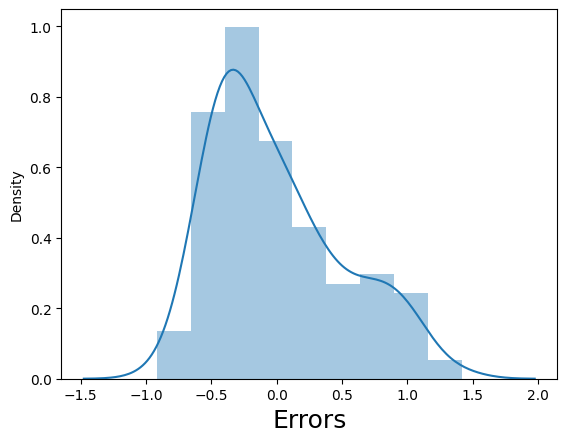

In [ ]:
res=y_train-y_train_pred
sns.distplot(res)
plt.xlabel('Errors', fontsize = 18)
plt.show()

 Making Predictions Using the Final Model

In [ ]:
numeric = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight','curbweight', 'enginesize', 'boreratio', 'stroke',
           'compressionratio','horsepower', 'peakrpm', 'citympg', 'highwaympg', 'doornumber', 'cylindernumber', 'price']

# Scale these variables using 'fit_transform'
df_test[numeric] = scaler.transform(df_test[numeric])

In [ ]:
col

Index(['CarName_audi 4000', 'CarName_bmw 320i', 'CarName_bmw x5',
       'CarName_volvo 244dl', 'CarName_volvo 246', 'CarName_volvo 264gl',
       'CarCompany_bmw', 'CarCompany_buick', 'CarCompany_jaguar',
       'CarCompany_porsche'],
      dtype='object')

In [ ]:
X_test=df_test
y_test=df_test.pop('price')

In [ ]:
X_test=X_test[col]
X_test.columns

Index(['CarName_audi 4000', 'CarName_bmw 320i', 'CarName_bmw x5',
       'CarName_volvo 244dl', 'CarName_volvo 246', 'CarName_volvo 264gl',
       'CarCompany_bmw', 'CarCompany_buick', 'CarCompany_jaguar',
       'CarCompany_porsche'],
      dtype='object')

In [ ]:
X_test_sm=sm.add_constant(X_test)
y_test_pred=lr_model.predict(X_test_sm)

In [ ]:
r2_score(y_true=y_test,y_pred=y_test_pred)

0.5914848255459746

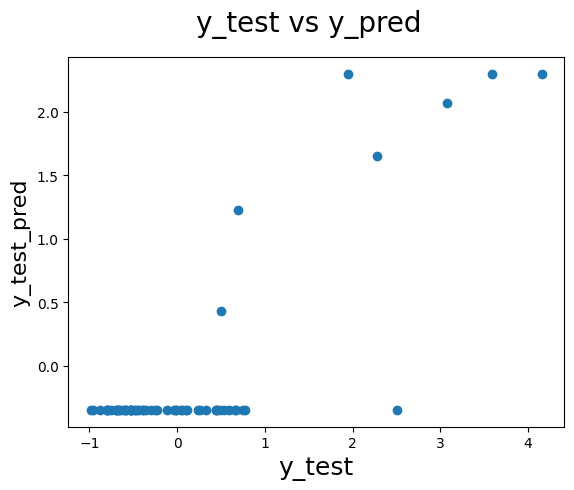

In [ ]:
plt.figure()
plt.scatter(y_test,y_test_pred)
plt.suptitle('y_test vs y_pred', fontsize = 20)              # Plot heading
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_test_pred', fontsize = 16)
plt.show()